In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [13]:
df = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    engine="python",
    on_bad_lines="skip"
)
df

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1208107,4,1988781759,Sun May 31 23:21:29 PDT 2009,NO_QUERY,thelarssan,@THErealDVORAK Thanks for sharing the website.
1208108,4,1988781871,Sun May 31 23:21:30 PDT 2009,NO_QUERY,Whobugs,After seeing the New Moon trailer the wait for...
1208109,4,1988781946,Sun May 31 23:21:31 PDT 2009,NO_QUERY,JacksonWhit,Ruth andIwatched it last night!!! Great minds ...
1208110,4,1988781958,Sun May 31 23:21:31 PDT 2009,NO_QUERY,emiliejayde,writing a song personal experience. a great5 ...


In [16]:
print(df.columns)

Index(['sentiment', 'tweet'], dtype='object')


In [20]:
df["sentiment"] = df["sentiment"].replace({
    0: "Negative",
    4: "Positive"
})

/tmp/ipykernel_3870/2949023241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment"] = df["sentiment"].replace({


In [21]:
df.dropna(inplace=True)

/tmp/ipykernel_3870/1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [23]:
X = df["tweet"]
y = df["sentiment"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Model
model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

In [25]:
y_pred = model.predict(X_test_vec)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))


Accuracy: 0.769525252149009
              precision    recall  f1-score   support

    Negative       0.77      0.94      0.84    159880
    Positive       0.79      0.44      0.56     81743

    accuracy                           0.77    241623
   macro avg       0.78      0.69      0.70    241623
weighted avg       0.77      0.77      0.75    241623



In [27]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

              precision    recall  f1-score   support

    Negative       0.77      0.94      0.84    159880
    Positive       0.79      0.44      0.56     81743

    accuracy                           0.77    241623
   macro avg       0.78      0.69      0.70    241623
weighted avg       0.77      0.77      0.75    241623


Confusion Matrix
[[150351   9529]
 [ 46159  35584]]


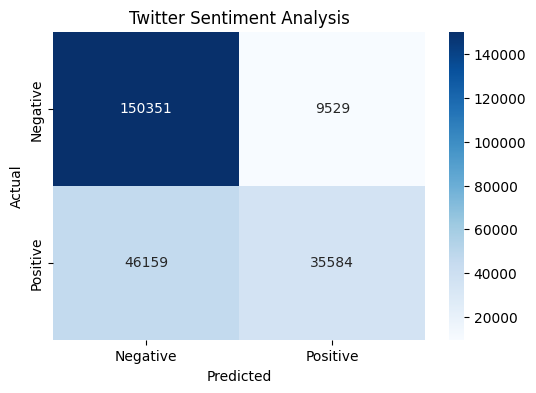

In [28]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Twitter Sentiment Analysis")

plt.show()

In [29]:
tweet = input("Enter Tweet: ")

tweet_vec = vectorizer.transform([tweet])

prediction = model.predict(tweet_vec)

print("Sentiment:", prediction[0])


Enter Tweet: good enternaiment platform
Sentiment: Positive
